## Assignment 8 – BERT Sentiment Analysis

1. Assignment Title - Implementation of Pre-trained BERT Model for Sentiment Analysis

## 2. Aim

To implement a pre-trained BERT (Bidirectional Encoder Representations from Transformers) model for sentiment analysis using a sample text dataset and classify text reviews into positive and negative sentiment categories.

## 3. Objectives
Understand the architecture and working principle of BERT.
Load a pre-trained BERT model.
Prepare and preprocess a text dataset.
Tokenize text using the BERT tokenizer.
Fine-tune BERT for sentiment classification.
Evaluate the model using accuracy, precision, recall and F1-score.
Visualize the classification performance using a confusion matrix.
Test the trained model on new text samples.
Document and upload the complete implementation to GitHub.

## 4. Implementation

 ## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset
Use the IMDB dataset provided through Hugging Face Datasets.

In [2]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


## Explore Dataset

Check the number of samples

In [4]:
print("Training samples:", len(dataset["train"]))
print("Testing samples:", len(dataset["test"]))


Training samples: 25000
Testing samples: 25000


Check labels

In [5]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}


Display a sample

In [6]:
print("Review:")
print(dataset["train"][0]["text"])

print("Label:")
print(dataset["train"][0]["label"])

Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far betw

## Visualize Class Distribution

In [13]:
import os
os.makedirs("results", exist_ok=True)

print("All libraries imported successfully!")

All libraries imported successfully!


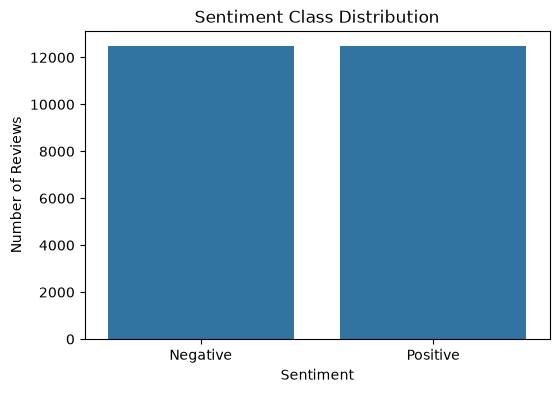

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = dataset["train"]["label"]

plt.figure(figsize=(6, 4))
sns.countplot(x=labels)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1], ["Negative", "Positive"])


plt.savefig("results/class_distribution.png")
plt.show()

## Load Pre-trained BERT Tokenizer

Use the pre-trained: bert-base-uncased

In [15]:
from transformers import AutoTokenizer

In [16]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

## Tokenization


Define a preprocessing function:

In [17]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

Apply tokenization:

In [18]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Check the result:

In [19]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})


## Reduce Dataset Size for Faster Execution

In [29]:

train_dataset = tokenized_dataset["train"].shuffle(seed=42).select(range(500))
test_dataset = tokenized_dataset["test"].shuffle(seed=42).select(range(200))

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 500
Testing samples: 200


## Load Pre-trained BERT Model

In [21]:
from transformers import AutoModelForSequenceClassification

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Define Evaluation Metrics

In [23]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## Training Configuration

In [24]:
from transformers import TrainingArguments

In [30]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

## Create Trainer

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


## Train the BERT Model

In [32]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.447183,0.825000,0.765217,0.916667,0.834123


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=63, training_loss=0.5076501937139601, metrics={'train_runtime': 408.0936, 'train_samples_per_second': 1.225, 'train_steps_per_second': 0.154, 'total_flos': 32888881920000.0, 'train_loss': 0.5076501937139601, 'epoch': 1.0})

## Evaluate Model

In [33]:
evaluation_results = trainer.evaluate()

print(evaluation_results)

C:\Users\Aksha\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,0.447183,1,0.825000,0.765217,0.916667,0.834123


{'eval_loss': 0.4471827745437622, 'eval_accuracy': 0.825, 'eval_precision': 0.7652173913043478, 'eval_recall': 0.9166666666666666, 'eval_f1': 0.8341232227488151}


## Make Predictions

In [34]:
predictions = trainer.predict(test_dataset)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

actual_labels = predictions.label_ids

C:\Users\Aksha\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## Classification Report

In [35]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.74      0.81       104
    Positive       0.77      0.92      0.83        96

    accuracy                           0.82       200
   macro avg       0.84      0.83      0.82       200
weighted avg       0.84      0.82      0.82       200



## Confusion Matrix

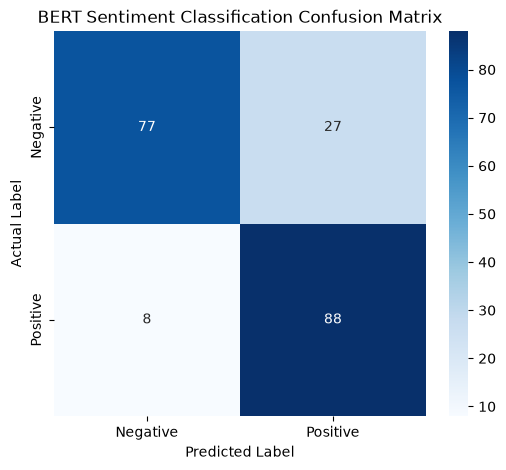

In [36]:
cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("BERT Sentiment Classification Confusion Matrix")

plt.savefig(
    "results/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

## Test on New Reviews

In [37]:
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    return "Positive" if prediction == 1 else "Negative"

In [38]:
reviews = [
    "The movie was absolutely amazing and I loved every scene.",
    "The movie was boring and a complete waste of time.",
    "The acting was excellent and the story was interesting.",
    "I did not enjoy the movie at all."
]

for review in reviews:
    print("Review:", review)
    print("Sentiment:", predict_sentiment(review))
    print("-" * 60)

Review: The movie was absolutely amazing and I loved every scene.
Sentiment: Positive
------------------------------------------------------------
Review: The movie was boring and a complete waste of time.
Sentiment: Negative
------------------------------------------------------------
Review: The acting was excellent and the story was interesting.
Sentiment: Positive
------------------------------------------------------------
Review: I did not enjoy the movie at all.
Sentiment: Negative
------------------------------------------------------------


## Save the Model

In [39]:
model.save_pretrained("./saved_bert_model")
tokenizer.save_pretrained("./saved_bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./saved_bert_model\\tokenizer_config.json',
 './saved_bert_model\\tokenizer.json')